# Exp7.3.5 — Hidden-state information loss across LIF quantization

Analysis-only notebook for the frozen Exp7.3 A2 hidden-state probes. The primary comparison is pre-threshold membrane versus binary spike at L1 and L2 under whole-sequence and ordered Fixed250 readouts.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_7_3_5_hidden_state_information_loss' / 'hidden_state_information_loss_v1'
manifest = json.loads((ART / 'manifest.json').read_text())
method_runs = pd.read_csv(ART / 'method_runs.csv')
method_summary = pd.read_csv(ART / 'method_summary.csv')
contrast_runs = pd.read_csv(ART / 'contrast_runs.csv')
contrast_summary = pd.read_csv(ART / 'contrast_summary.csv')
source_checks = pd.read_csv(ART / 'source_reproduction_checks.csv')
manifest

{'C_grid': [0.001, 0.01, 0.1, 1.0, 10.0],
 'aggregations': ['whole_mean', 'fixed250_ordered_mean'],
 'architecture': '234x234',
 'completed_probe_tasks': 48,
 'expected_extraction_tasks': 3,
 'expected_probe_tasks': 48,
 'experiment_id': 'experiment_7_3_5_hidden_state_information_loss',
 'interpretation': {'near_zero_spike_quantization_pre_minus_spike': 'binary hidden spikes preserve nearly all linearly accessible information measured by this probe',
  'positive_spike_quantization_pre_minus_spike': 'pre-threshold membrane contains more linearly accessible test information than binary spikes'},
 'layers': ['l1', 'l2'],
 'primary_contrasts': ['membrane_integration_pre_minus_current',
  'spike_quantization_pre_minus_spike'],
 'primary_states': ['syn_current', 'pre_reset', 'spike'],
 'protocol_version': 'hidden_state_information_loss_v1',
 'secondary_contrasts': ['reset_pre_minus_post', 'postreset_minus_spike'],
 'secondary_states': ['post_reset'],
 'seeds': [11, 23, 37],
 'source_method':

## Primary method summary
The three primary hidden states are synaptic current, pre-reset membrane, and binary spike. Post-reset membrane is retained only as a secondary reset diagnostic.

In [2]:
primary = method_summary[method_summary['state_role'] == 'primary'].copy()
cols = ['aggregation', 'layer', 'state', 'test_ba_mean', 'test_ba_std', 'val_ba_mean', 'selected_C_mean']
primary[cols].sort_values(['aggregation', 'layer', 'state'])

,aggregation,layer,state,test_ba_mean,test_ba_std,val_ba_mean,selected_C_mean
1,fixed250_ordered_mean,l1,pre_reset,0.623111,0.010642,0.574008,0.04
2,fixed250_ordered_mean,l1,spike,0.551411,0.030667,0.539165,0.10
3,fixed250_ordered_mean,l1,syn_current,0.613121,0.021004,0.590426,4.00
5,fixed250_ordered_mean,l2,pre_reset,0.586965,0.008153,0.564833,0.10
6,fixed250_ordered_mean,l2,spike,0.618353,0.021818,0.592983,0.10
7,fixed250_ordered_mean,l2,syn_current,0.595508,0.011940,0.578004,0.07
9,whole_mean,l1,pre_reset,0.535259,0.027038,0.541462,10.00
10,whole_mean,l1,spike,0.564751,0.024849,0.533842,1.00
11,whole_mean,l1,syn_current,0.494105,0.013867,0.512163,10.00
13,whole_mean,l2,pre_reset,0.539398,0.015798,0.546761,10.00


## Whole-sequence information
Within each layer, compare `syn_current -> pre_reset -> spike`. A large drop from pre-reset membrane to spike indicates hidden binary quantization loss even without an output spiking neuron.

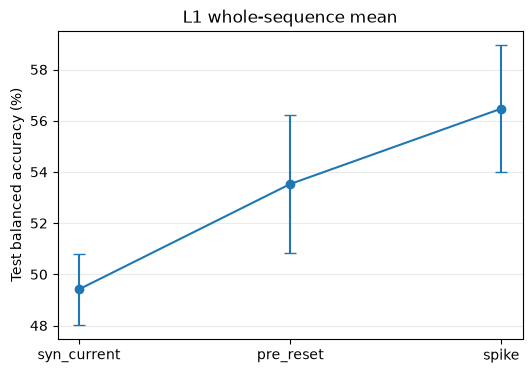

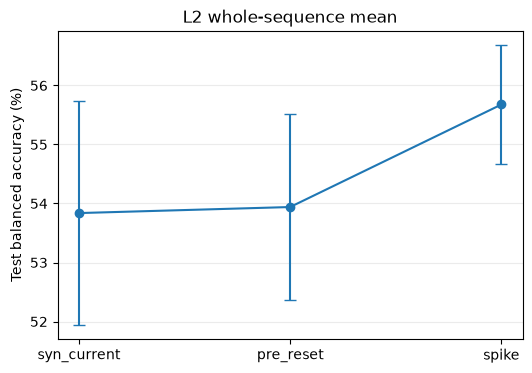

In [3]:
state_order = ['syn_current', 'pre_reset', 'spike']
for layer in ['l1', 'l2']:
    frame = primary[(primary['aggregation'] == 'whole_mean') & (primary['layer'] == layer)].set_index('state').loc[state_order]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(state_order, 100 * frame['test_ba_mean'], yerr=100 * frame['test_ba_std'], marker='o', capsize=4)
    ax.set_ylabel('Test balanced accuracy (%)')
    ax.set_title(f'{layer.upper()} whole-sequence mean')
    ax.grid(axis='y', alpha=0.25)
    plt.show()

## Ordered Fixed250 temporal information
This view retains absolute 250 ms bin order. A larger membrane-to-spike gap here than in whole-mean indicates preferential loss of temporal/phase information.

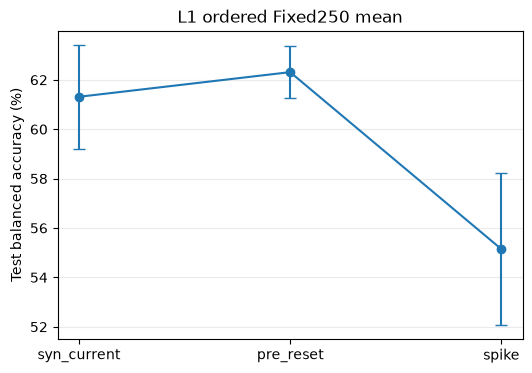

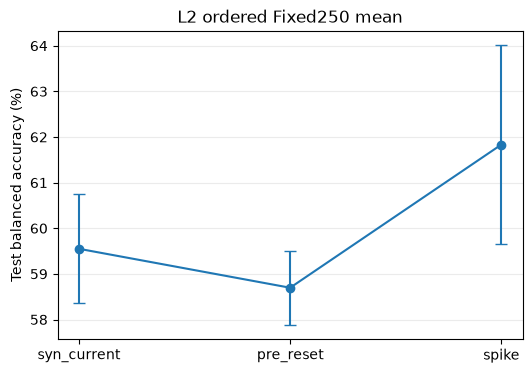

In [4]:
for layer in ['l1', 'l2']:
    frame = primary[(primary['aggregation'] == 'fixed250_ordered_mean') & (primary['layer'] == layer)].set_index('state').loc[state_order]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(state_order, 100 * frame['test_ba_mean'], yerr=100 * frame['test_ba_std'], marker='o', capsize=4)
    ax.set_ylabel('Test balanced accuracy (%)')
    ax.set_title(f'{layer.upper()} ordered Fixed250 mean')
    ax.grid(axis='y', alpha=0.25)
    plt.show()

## Primary information-loss contrasts
Positive `spike_quantization_pre_minus_spike` means the pre-threshold membrane retains more linearly accessible information than the binary spike. Positive `membrane_integration_pre_minus_current` means membrane integration improves accessibility relative to synaptic current.

In [5]:
primary_contrasts = contrast_summary[contrast_summary['contrast'].isin(manifest['primary_contrasts'])].copy()
primary_contrasts.sort_values(['aggregation', 'layer', 'contrast'])

,contrast,layer,aggregation,count,mean,std
1,membrane_integration_pre_minus_current,l1,fixed250_ordered_mean,3,0.999001,1.179811
5,spike_quantization_pre_minus_spike,l1,fixed250_ordered_mean,3,7.170029,2.723382
3,membrane_integration_pre_minus_current,l2,fixed250_ordered_mean,3,-0.854308,0.741383
7,spike_quantization_pre_minus_spike,l2,fixed250_ordered_mean,3,-3.138829,2.977853
0,membrane_integration_pre_minus_current,l1,whole_mean,3,4.115422,1.976912
4,spike_quantization_pre_minus_spike,l1,whole_mean,3,-2.949250,5.152679
2,membrane_integration_pre_minus_current,l2,whole_mean,3,0.102374,0.447246
6,spike_quantization_pre_minus_spike,l2,whole_mean,3,-1.737753,2.304754


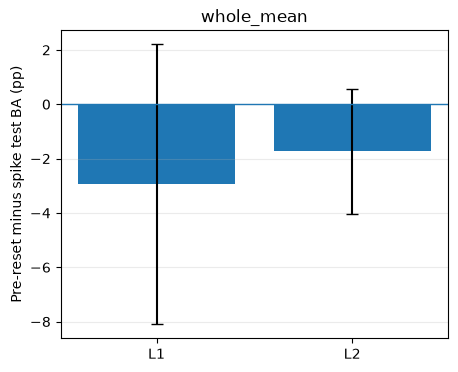

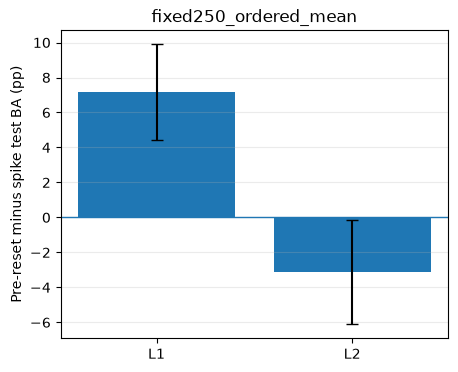

In [6]:
quant = primary_contrasts[primary_contrasts['contrast'] == 'spike_quantization_pre_minus_spike'].copy()
for aggregation in ['whole_mean', 'fixed250_ordered_mean']:
    frame = quant[quant['aggregation'] == aggregation].set_index('layer').loc[['l1', 'l2']]
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(['L1', 'L2'], frame['mean'], yerr=frame['std'], capsize=4)
    ax.axhline(0, linewidth=1)
    ax.set_ylabel('Pre-reset minus spike test BA (pp)')
    ax.set_title(aggregation)
    ax.grid(axis='y', alpha=0.25)
    plt.show()

## Secondary reset diagnostics

In [7]:
secondary = contrast_summary[contrast_summary['contrast'].isin(manifest['secondary_contrasts'])].copy()
secondary.sort_values(['aggregation', 'layer', 'contrast'])

,contrast,layer,aggregation,count,mean,std
13,postreset_minus_spike,l1,fixed250_ordered_mean,3,4.446595,2.845975
9,reset_pre_minus_post,l1,fixed250_ordered_mean,3,2.723434,0.730464
15,postreset_minus_spike,l2,fixed250_ordered_mean,3,-4.316216,2.211670
11,reset_pre_minus_post,l2,fixed250_ordered_mean,3,1.177387,2.207384
12,postreset_minus_spike,l1,whole_mean,3,-1.971316,3.415567
8,reset_pre_minus_post,l1,whole_mean,3,-0.977934,3.384782
14,postreset_minus_spike,l2,whole_mean,3,-4.216270,3.963223
10,reset_pre_minus_post,l2,whole_mean,3,2.478517,4.285664


## Source replay audit
All rows should stay within the manifest's extraction tolerance. This verifies that the diagnostic replay uses the same L2 binary-spike realization as the frozen Exp7.3 A2 cache.

In [8]:
source_checks.sort_values(['seed', 'split', 'aggregation'])

,seed,split,aggregation,l2_spike_replay_max_abs_delta,tolerance
0,11,test,fixed250_ordered_mean,0.0,0.000001
1,11,test,whole_mean,0.0,0.000001
2,11,train,fixed250_ordered_mean,0.0,0.000001
3,11,train,whole_mean,0.0,0.000001
4,11,val,fixed250_ordered_mean,0.0,0.000001
5,11,val,whole_mean,0.0,0.000001
6,23,test,fixed250_ordered_mean,0.0,0.000001
7,23,test,whole_mean,0.0,0.000001
8,23,train,fixed250_ordered_mean,0.0,0.000001
9,23,train,whole_mean,0.0,0.000001
